In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re
import os
import sys
import requests
import time

In [33]:
API_KEY = "26b14325ac8aae8c4e37cce46a3b1b69"

headers = {
    "x-apisports-key": API_KEY
}

In [34]:
url = "https://v3.football.api-sports.io/fixtures"

params = {
    "league": 39,   #premier league
    "season": 2023    
}

response = requests.get(url, headers=headers, params=params)

data = response.json()

In [35]:
print(data.keys())

dict_keys(['get', 'parameters', 'errors', 'results', 'paging', 'response'])


In [36]:
import json
print(json.dumps(data, indent=4))


{
    "get": "fixtures",
    "parameters": {
        "league": "39",
        "season": "2023"
    },
    "errors": {
        "access": "Your account is suspended, check on https://dashboard.api-football.com."
    },
    "results": 0,
    "paging": {
        "current": 1,
        "total": 1
    },
    "response": []
}


In [37]:
matches = data["response"] #Full season

print(len(matches))

0


In [38]:
match_list = []

for match in matches:
    match_info = {
        # Core Info
        "match_id": match["fixture"]["id"],
        "date": match["fixture"]["date"],
        "league_round": match["league"]["round"],
        "referee": match["fixture"]["referee"],
        "venue_name": match["fixture"]["venue"]["name"],
        "venue_city": match["fixture"]["venue"]["city"],

        # teams
        "home_team": match["teams"]["home"]["name"],
        "away_team": match["teams"]["away"]["name"],
        "home_team_id": match["teams"]["home"]["id"],
        "away_team_id": match["teams"]["away"]["id"],

        # scores
        "home_goals": match["goals"]["home"],
        "away_goals": match["goals"]["away"],

        # halftime & fulltime scores
        "halftime_home": match["score"]["halftime"]["home"],
        "halftime_away": match["score"]["halftime"]["away"],
        "fulltime_home": match["score"]["fulltime"]["home"],
        "fulltime_away": match["score"]["fulltime"]["away"],

        # Match Status
        "status": match["fixture"]["status"]["long"]
    }

    match_list.append(match_info)



In [39]:
df_matches = pd.DataFrame(match_list)

print("df_matches created:", df_matches.shape)


df_matches created: (0, 0)


In [40]:
df_finished = df_matches[df_matches["status"]]

print("Finished matches:", len(df_finished))

KeyError: 'status'

In [ ]:
print(type(df_matches))


<class 'pandas.DataFrame'>


In [ ]:
df_matches.shape
df_matches.head()


NameError: name 'df_matches' is not defined

In [ ]:
#functions


def get_match_stats(fixture_id):
    stats_url = "https://v3.football.api-sports.io/fixtures/statistics"
    params = {"fixture": fixture_id}
    response = requests.get(stats_url, headers=headers, params=params)
    return response.json()


def extract_stat(stats_list, stat_name):
    for item in stats_list:
        if item["type"] == stat_name:
            return item["value"]
    return None


def clean_percentage(value):
    if value is None:
        return None
    return float(value.replace("%", ""))





In [ ]:

batch1 = df_finished.iloc[0:100]

stats_collection = []

for fixture_id in batch1["match_id"]:
    try:
        stats_data = get_match_stats(fixture_id)

        if not stats_data.get("response"):
            continue

        stats = stats_data["response"]

        if len(stats) < 2:
            continue

        home_stats = stats[0]["statistics"]
        away_stats = stats[1]["statistics"]

        row = {
            "match_id": fixture_id,
            "home_total_shots": extract_stat(home_stats, "Total Shots"),
            "away_total_shots": extract_stat(away_stats, "Total Shots"),
            "home_shots_on_target": extract_stat(home_stats, "Shots on Goal"),
            "away_shots_on_target": extract_stat(away_stats, "Shots on Goal"),
            "home_xg": extract_stat(home_stats, "expected_goals"),
            "away_xg": extract_stat(away_stats, "expected_goals"),
            "home_possession": clean_percentage(
                extract_stat(home_stats, "Ball Possession")
            ),
            "away_possession": clean_percentage(
                extract_stat(away_stats, "Ball Possession")
            )
        }

        stats_collection.append(row)

        time.sleep(3)  # caused rate limit issue

    except Exception as e:
        print("Error:", e)
        continue


NameError: name 'df_finished' is not defined

In [ ]:
df_batch1 = pd.DataFrame(stats_collection)

print("Rows collected in Batch 1:", len(df_batch1))

# we saved to avoid losing our progress
df_batch1.to_csv("stats_batch1.csv", index=False)


Rows collected in Batch 1: 50


In [ ]:
df_batch1.head()


,match_id,home_total_shots,away_total_shots,home_shots_on_target,away_shots_on_target,home_xg,away_xg,home_shots_inside_box,away_shots_inside_box,home_shots_outside_box,away_shots_outside_box,home_possession,away_possession
0,1035037,6,17,1,8,0.33,2.08,5,14,1,3,34.0,66.0
1,1035038,15,6,7,2,0.83,1.18,8,4,7,2,78.0,22.0
2,1035039,14,16,5,3,1.37,1.07,5,12,9,4,63.0,37.0
3,1035041,19,9,9,2,2.73,1.50,14,6,5,3,41.0,59.0
4,1035040,27,9,12,3,4.01,1.48,20,7,7,2,71.0,29.0


In [ ]:

#LOADING EXISTING POSSESSION

if os.path.exists("possession_master.csv"):
    df_existing = pd.read_csv("possession_master.csv")
    print("Existing possession rows:", len(df_existing))
else:
    df_existing = pd.DataFrame(
        columns=["match_id", "home_possession", "away_possession"]
    )
    print("Starting fresh.")

existing_ids = df_existing["match_id"].tolist()


Existing possession rows: 64


In [ ]:

# SELECT MATCHES 65–165

all_finished_ids = df_finished["match_id"].tolist()

remaining_ids = [mid for mid in all_finished_ids if mid not in existing_ids]

print("Remaining matches:", len(remaining_ids))




NameError: name 'df_finished' is not defined

In [ ]:
batch3_ids = remaining_ids[:100]

print("Batch 3 size:", len(batch3_ids))

Batch 3 size: 0


In [ ]:

#BATCH 3 POSSESSION EXTRACTION

def extract_possession(stats_list):
    for item in stats_list:
        if item["type"] == "Ball Possession":
            return float(item["value"].replace("%", ""))
    return None


batch3_collection = []
request_count = 0

for fixture_id in batch3_ids:
    try:
        response = requests.get(
            "https://v3.football.api-sports.io/fixtures/statistics",
            headers=headers,
            params={"fixture": fixture_id},
            timeout=10
        )

        stats_data = response.json()

        if not stats_data.get("response"):
            print("No response:", fixture_id)
            continue

        stats = stats_data["response"]

        if len(stats) < 2:
            continue

        row = {
            "match_id": fixture_id,
            "home_possession": extract_possession(stats[0]["statistics"]),
            "away_possession": extract_possession(stats[1]["statistics"])
        }

        batch3_collection.append(row)

        request_count += 1
        print("Batch 3 requests used:", request_count)

        time.sleep(10)  # safe rate control

    except Exception as e:
        print("Error:", e)
        continue


In [ ]:
# MERGE & SAVE

df_batch3 = pd.DataFrame(batch3_collection)

print("Batch 3 rows collected:", len(df_batch3))

df_updated = pd.concat([df_existing, df_batch3], ignore_index=True)
df_updated.drop_duplicates(subset="match_id", inplace=True)

df_updated.to_csv("possession_master.csv", index=False)

print("Total possession rows after merge:", len(df_updated))


Batch 3 rows collected: 0
Total possession rows after merge: 64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid") 
plt.rcParams["figure.figsize"] = (10,6)


In [41]:
#DATASET SECTION
df= pd.read_csv("season-2324.csv")

df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,11/08/23,Burnley,Man City,0,3,A,0,2,A,C Pawson,...,1,8,11,8,6,5,0,0,1,0
1,12/08/23,Arsenal,Nott'm Forest,2,1,H,2,0,H,M Oliver,...,7,2,12,12,8,3,2,2,0,0
2,12/08/23,Bournemouth,West Ham,1,1,D,0,0,D,P Bankes,...,5,3,9,14,10,4,1,4,0,0
3,12/08/23,Brighton,Luton,4,1,H,1,0,H,D Coote,...,12,3,11,12,6,7,2,2,0,0
4,12/08/23,Everton,Fulham,0,1,A,0,0,D,S Attwell,...,9,2,12,6,10,4,0,2,0,0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      380 non-null    object
 1   HomeTeam  380 non-null    object
 2   AwayTeam  380 non-null    object
 3   FTHG      380 non-null    int64 
 4   FTAG      380 non-null    int64 
 5   FTR       380 non-null    object
 6   HTHG      380 non-null    int64 
 7   HTAG      380 non-null    int64 
 8   HTR       380 non-null    object
 9   Referee   380 non-null    object
 10  HS        380 non-null    int64 
 11  AS        380 non-null    int64 
 12  HST       380 non-null    int64 
 13  AST       380 non-null    int64 
 14  HF        380 non-null    int64 
 15  AF        380 non-null    int64 
 16  HC        380 non-null    int64 
 17  AC        380 non-null    int64 
 18  HY        380 non-null    int64 
 19  AY        380 non-null    int64 
 20  HR        380 non-null    int64 
 21  AR        380 no

In [43]:
print(df.columns)

Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG',
       'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC',
       'HY', 'AY', 'HR', 'AR'],
      dtype='object')


In [44]:
df = df.rename(columns={
    "FTHG": "home_goals",
    "FTAG": "away_goals",
    "HS": "home_shots",
    "AS": "away_shots",
    "HST": "home_shots_on_target",
    "AST": "away_shots_on_target",
    "HY": "home_yellow",
    "AY": "away_yellow",
    "HR": "home_red",
    "AR": "away_red",
    "FTR": "result"
})


In [45]:
df["home_shot_accuracy"] = (df["home_shots_on_target"] / df["home_shots"]) * 100
df["away_shot_accuracy"] = (df["away_shots_on_target"] / df["away_shots"]) * 100

df["home_conversion"] = df["home_goals"] / df["home_shots"]*100
df["away_conversion"] = df["away_goals"] / df["away_shots"]*100

df.fillna(0, inplace=True)


In [46]:
home_df = df[[
    "HomeTeam","home_goals","home_shots","home_shot_accuracy",
    "home_conversion","home_yellow","home_red","result"
]].copy()

home_df.columns = [
    "Team","Goals","Shots","Accuracy",
    "Conversion","Yellow","Red","Result"
]

home_df["Points"] = home_df["Result"].map({
    "H":3,"D":1,"A":0
})


In [47]:
away_df = df[[
    "AwayTeam","away_goals","away_shots","away_shot_accuracy",
    "away_conversion","away_yellow","away_red","result"
]].copy()

away_df.columns = [
    "Team","Goals","Shots","Accuracy",
    "Conversion","Yellow","Red","Result"
]

away_df["Points"] = away_df["Result"].map({
    "A":3,"D":1,"H":0
})


In [48]:
team_df = pd.concat([home_df, away_df], ignore_index=True)
team_df.head()


,Team,Goals,Shots,Accuracy,Conversion,Yellow,Red,Result,Points
0,Burnley,0,6,16.666667,0.000000,0,1,A,0
1,Arsenal,2,15,46.666667,13.333333,2,0,H,3
2,Bournemouth,1,14,35.714286,7.142857,1,0,D,1
3,Brighton,4,27,44.444444,14.814815,2,0,H,3
4,Everton,0,19,47.368421,0.000000,0,0,A,0


In [49]:
team_df.shape

(760, 9)

In [50]:
print(df.columns)


Index(['Date', 'HomeTeam', 'AwayTeam', 'home_goals', 'away_goals', 'result',
       'HTHG', 'HTAG', 'HTR', 'Referee', 'home_shots', 'away_shots',
       'home_shots_on_target', 'away_shots_on_target', 'HF', 'AF', 'HC', 'AC',
       'home_yellow', 'away_yellow', 'home_red', 'away_red',
       'home_shot_accuracy', 'away_shot_accuracy', 'home_conversion',
       'away_conversion'],
      dtype='object')


In [51]:
team_summary = team_df.groupby("Team").agg({
    "Goals":"sum",
    "Shots":"sum",
    "Accuracy":"mean",
    "Conversion":"mean",
    "Yellow":"sum",
    "Red":"sum",
    "Points":"sum"
}).reset_index()


In [52]:
team_summary.head()

,Team,Goals,Shots,Accuracy,Conversion,Yellow,Red,Points
0,Arsenal,91,657,34.426856,13.873220,62,2,89
1,Aston Villa,76,514,37.031140,14.460051,94,2,68
2,Bournemouth,54,542,34.088264,10.365647,80,3,48
3,Brentford,56,473,39.419795,12.345362,88,2,39
4,Brighton,55,562,37.050785,10.388443,89,3,48


In [53]:
team_summary = team_summary.sort_values(
    by="Points",ascending=False
).reset_index(drop=True)

team_summary["Position"] = team_summary.index + 1

team_summary.head()


,Team,Goals,Shots,Accuracy,Conversion,Yellow,Red,Points,Position
0,Man City,96,690,43.014918,15.270857,51,2,91,1
1,Arsenal,91,657,34.426856,13.873220,62,2,89,2
2,Liverpool,86,790,35.036890,11.953148,65,5,82,3
3,Aston Villa,76,514,37.031140,14.460051,94,2,68,4
4,Tottenham,74,582,37.793983,13.772467,88,4,66,5


In [54]:
team_summary.tail(5)

,Team,Goals,Shots,Accuracy,Conversion,Yellow,Red,Points,Position
15,Brentford,56,473,39.419795,12.345362,88,2,39,16
16,Nott'm Forest,49,451,33.483049,11.363039,75,3,36,17
17,Luton,52,431,34.673454,13.990765,71,0,26,18
18,Burnley,41,433,31.897741,9.267356,71,7,24,19
19,Sheffield United,35,368,33.747008,9.609423,93,5,16,20


Hypothesis 1 - Shot Accuracy increases probability of winning

In [55]:
h1=team_summary.groupby('Position')['Accuracy'].mean()
print (h1)

Position
1     43.014918
2     34.426856
3     35.036890
4     37.031140
5     37.793983
6     41.616482
7     34.514543
8     39.463162
9     35.514916
10    39.225285
11    32.730606
12    37.050785
13    34.088264
14    39.686422
15    40.608418
16    39.419795
17    33.483049
18    34.673454
19    31.897741
20    33.747008
Name: Accuracy, dtype: float64


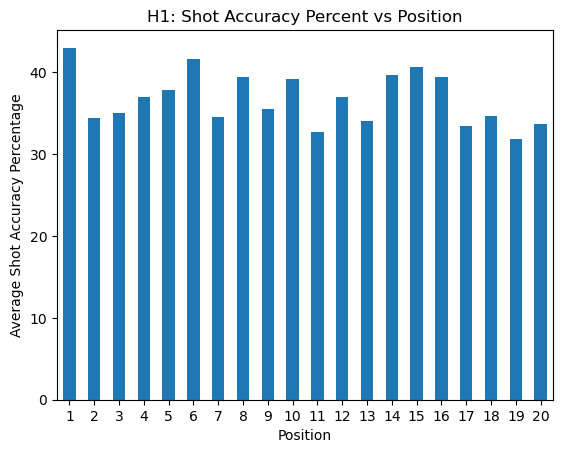

In [56]:
h1.plot(kind='bar')

plt.title("H1: Shot Accuracy Percent vs Position")
plt.ylabel("Average Shot Accuracy Percentage")
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20'], rotation=0)

plt.show()

Shot Accuracy alone cannot be stated as parameter to decide position in league table

Hypothesis 2- Goal conversion is a stronger predictor of league outcome compared to shot accurarcy

In [57]:
h2=team_summary.groupby('Position')['Conversion'].mean()
print(h2)

Position
1     15.270857
2     13.873220
3     11.953148
4     14.460051
5     13.772467
6     15.547042
7     11.277680
8     16.308912
9     15.198753
10    13.760859
11     9.120867
12    10.388443
13    10.365647
14    11.517734
15    14.413914
16    12.345362
17    11.363039
18    13.990765
19     9.267356
20     9.609423
Name: Conversion, dtype: float64


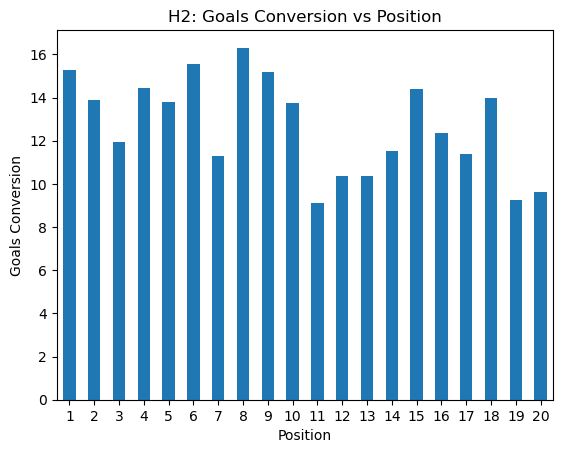

In [58]:
h2.plot(kind='bar')

plt.title("H2: Goals Conversion vs Position")
plt.ylabel("Goals Conversion")
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20'], rotation=0)

plt.show()

Hypothesis 3- discipline

In [59]:
team_summary["Discipline_Score"] = team_summary["Yellow"] + (team_summary["Red"] * 2)

In [ ]:
team_summary.head()

,Team,Goals,Shots,Accuracy,Conversion,Yellow,Red,Points,Position,Discipline_Score
0,Man City,96,690,43.014918,15.270857,51,2,91,1,55
1,Arsenal,91,657,34.426856,13.873220,62,2,89,2,66
2,Liverpool,86,790,35.036890,11.953148,65,5,82,3,75
3,Aston Villa,76,514,37.031140,14.460051,94,2,68,4,98
4,Tottenham,74,582,37.793983,13.772467,88,4,66,5,96


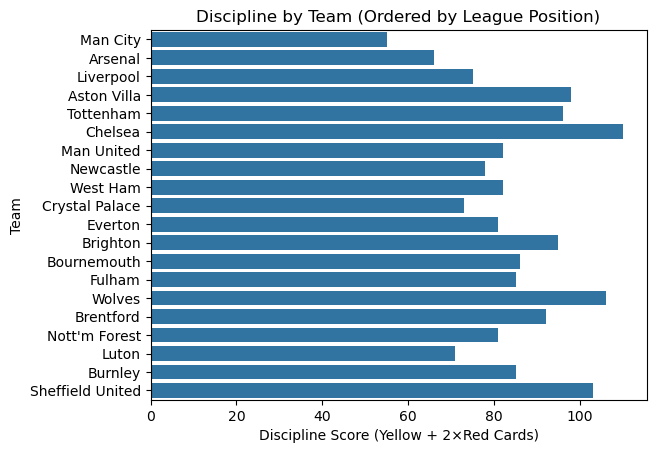

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=team_summary.sort_values("Position"),
    x="Discipline_Score",
    y="Team"
)

plt.title("Discipline by Team (Ordered by League Position)")
plt.xlabel("Discipline Score (Yellow + 2×Red Cards)")
plt.ylabel("Team")
plt.show()

Discipline score less suggest that team has done less foul play.So Clearly team 1 has made less foul play

Hypotheis 4- Most teams with higher possession of the ball, convert more goals

In [62]:
df_64 = df.head(64)

df_64.head()

,Date,HomeTeam,AwayTeam,home_goals,away_goals,result,HTHG,HTAG,HTR,Referee,...,HC,AC,home_yellow,away_yellow,home_red,away_red,home_shot_accuracy,away_shot_accuracy,home_conversion,away_conversion
0,11/08/23,Burnley,Man City,0,3,A,0,2,A,C Pawson,...,6,5,0,0,1,0,16.666667,47.058824,0.000000,17.647059
1,12/08/23,Arsenal,Nott'm Forest,2,1,H,2,0,H,M Oliver,...,8,3,2,2,0,0,46.666667,33.333333,13.333333,16.666667
2,12/08/23,Bournemouth,West Ham,1,1,D,0,0,D,P Bankes,...,10,4,1,4,0,0,35.714286,18.750000,7.142857,6.250000
3,12/08/23,Brighton,Luton,4,1,H,1,0,H,D Coote,...,6,7,2,2,0,0,44.444444,33.333333,14.814815,11.111111
4,12/08/23,Everton,Fulham,0,1,A,0,0,D,S Attwell,...,10,4,0,2,0,0,47.368421,22.222222,0.000000,11.111111


In [64]:
possession_df = pd.read_csv("possession_master.csv")

possession_df.columns

Index(['match_id', 'home_total_shots', 'away_total_shots',
       'home_shots_on_target', 'away_shots_on_target', 'home_xg', 'away_xg',
       'home_shots_inside_box', 'away_shots_inside_box',
       'home_shots_outside_box', 'away_shots_outside_box', 'home_possession',
       'away_possession'],
      dtype='object')

In [65]:
possession_df = possession_df.drop(columns=[
    "home_total_shots", "away_total_shots",
    "home_shots_on_target", "away_shots_on_target",
    "home_xg", "away_xg",
    "home_shots_inside_box", "away_shots_inside_box",
    "home_shots_outside_box", "away_shots_outside_box"
])

In [66]:
possession_df.head()

,match_id,home_possession,away_possession
0,1035037,34.0,66.0
1,1035038,78.0,22.0
2,1035039,63.0,37.0
3,1035041,41.0,59.0
4,1035040,71.0,29.0


In [67]:
merged_df = pd.concat([df_64, possession_df], axis=1)

merged_df.head()

,Date,HomeTeam,AwayTeam,home_goals,away_goals,result,HTHG,HTAG,HTR,Referee,...,away_yellow,home_red,away_red,home_shot_accuracy,away_shot_accuracy,home_conversion,away_conversion,match_id,home_possession,away_possession
0,11/08/23,Burnley,Man City,0,3,A,0,2,A,C Pawson,...,0,1,0,16.666667,47.058824,0.000000,17.647059,1035037,34.0,66.0
1,12/08/23,Arsenal,Nott'm Forest,2,1,H,2,0,H,M Oliver,...,2,0,0,46.666667,33.333333,13.333333,16.666667,1035038,78.0,22.0
2,12/08/23,Bournemouth,West Ham,1,1,D,0,0,D,P Bankes,...,4,0,0,35.714286,18.750000,7.142857,6.250000,1035039,63.0,37.0
3,12/08/23,Brighton,Luton,4,1,H,1,0,H,D Coote,...,2,0,0,44.444444,33.333333,14.814815,11.111111,1035041,41.0,59.0
4,12/08/23,Everton,Fulham,0,1,A,0,0,D,S Attwell,...,2,0,0,47.368421,22.222222,0.000000,11.111111,1035040,71.0,29.0


In [68]:
merged_df.columns

Index(['Date', 'HomeTeam', 'AwayTeam', 'home_goals', 'away_goals', 'result',
       'HTHG', 'HTAG', 'HTR', 'Referee', 'home_shots', 'away_shots',
       'home_shots_on_target', 'away_shots_on_target', 'HF', 'AF', 'HC', 'AC',
       'home_yellow', 'away_yellow', 'home_red', 'away_red',
       'home_shot_accuracy', 'away_shot_accuracy', 'home_conversion',
       'away_conversion', 'match_id', 'home_possession', 'away_possession'],
      dtype='object')

In [69]:
h3=merged_df.groupby(['HomeTeam'])['home_possession'].mean()
print(h3)

HomeTeam
Arsenal             58.000000
Aston Villa         43.000000
Bournemouth         59.000000
Brentford           47.000000
Brighton            51.750000
Burnley             54.500000
Chelsea             61.750000
Crystal Palace      45.333333
Everton             66.500000
Fulham              64.500000
Liverpool           26.000000
Luton               38.000000
Man City            46.333333
Man United          60.250000
Newcastle           55.000000
Nott'm Forest       65.500000
Sheffield United    45.000000
Tottenham           67.000000
West Ham            57.000000
Wolves              53.500000
Name: home_possession, dtype: float64


In [70]:
h4=merged_df.groupby(['AwayTeam'])['away_possession'].mean()
print(h4)

AwayTeam
Arsenal             45.666667
Aston Villa         47.500000
Bournemouth         43.333333
Brentford           38.000000
Brighton            56.666667
Burnley             30.500000
Chelsea             28.000000
Crystal Palace      56.000000
Everton             52.000000
Fulham              53.500000
Liverpool           46.666667
Luton               46.000000
Man City            55.666667
Man United          34.666667
Newcastle           47.000000
Nott'm Forest       33.000000
Sheffield United    36.500000
Tottenham           51.750000
West Ham            64.500000
Wolves              43.000000
Name: away_possession, dtype: float64


In [71]:
home_data = merged_df[['HomeTeam', 'home_possession']].copy()
home_data.columns = ['Team', 'Possession']

In [72]:
away_data = merged_df[['AwayTeam', 'away_possession']].copy()
away_data.columns = ['Team', 'Possession']

In [73]:
combined = pd.concat([home_data, away_data], axis=0)

In [74]:
team_possession = combined.groupby('Team')['Possession'].mean().sort_values(ascending=False)

In [75]:
print(team_possession)

Team
West Ham            62.000000
Everton             60.285714
Fulham              57.166667
Tottenham           56.833333
Brighton            53.857143
Arsenal             52.714286
Bournemouth         52.285714
Newcastle           51.571429
Crystal Palace      51.428571
Man City            51.000000
Chelsea             50.500000
Man United          49.285714
Wolves              46.500000
Burnley             46.500000
Aston Villa         45.571429
Brentford           44.000000
Nott'm Forest       43.833333
Luton               43.333333
Sheffield United    42.166667
Liverpool           36.333333
Name: Possession, dtype: float64


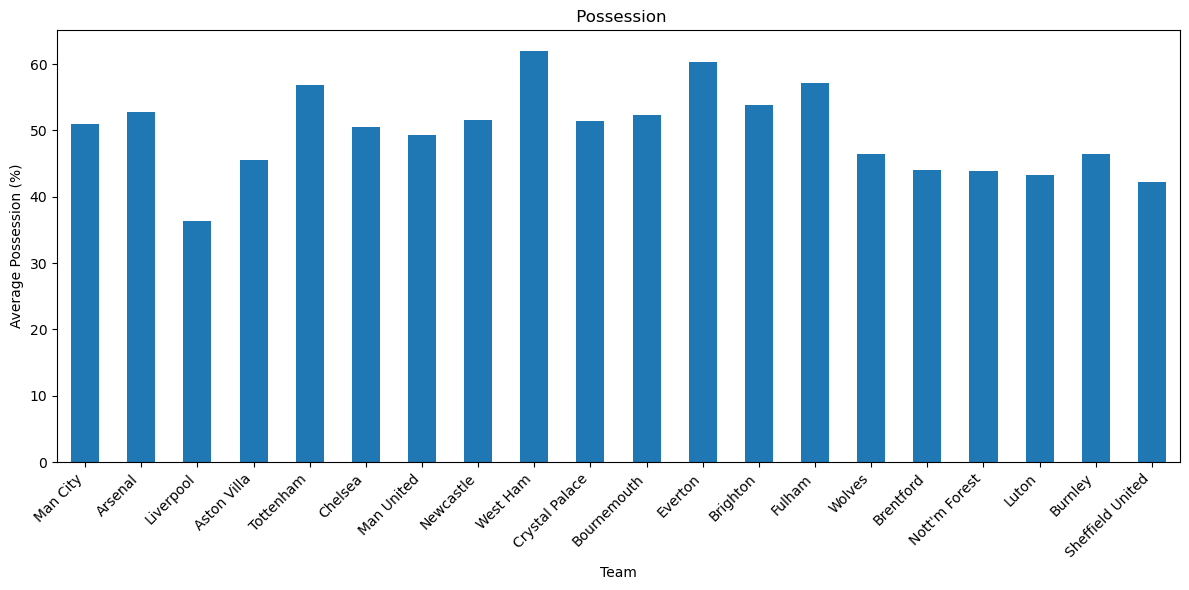

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Team": ["West Ham", "Everton", "Fulham", "Tottenham", "Brighton", "Arsenal", 
             "Bournemouth", "Newcastle", "Crystal Palace", "Man City", "Chelsea",
             "Man United", "Wolves", "Burnley", "Aston Villa", "Brentford", 
             "Nott'm Forest", "Luton", "Sheffield United", "Liverpool"],
    "Possession": [62.0, 60.285714, 57.166667, 56.833333, 53.857143, 52.714286,
                   52.285714, 51.571429, 51.428571, 51.0, 50.5, 49.285714,
                   46.5, 46.5, 45.571429, 44.0, 43.833333, 43.333333, 42.166667, 36.333333]
}

team_possession = pd.DataFrame(data)
team_possession.set_index("Team", inplace=True)

custom_order = ["Man City","Arsenal","Liverpool","Aston Villa","Tottenham",
                "Chelsea","Man United","Newcastle","West Ham","Crystal Palace",
                "Bournemouth","Everton","Brighton","Fulham","Wolves","Brentford",
                "Nott'm Forest","Luton","Burnley","Sheffield United"]

team_possession = team_possession.loc[custom_order]
plt.figure(figsize=(12,6))
team_possession["Possession"].plot(kind="bar")
plt.ylabel("Average Possession (%)")
plt.title(" Possession")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Hypothesis 5(Top 5 and Bottom 5 Teams)

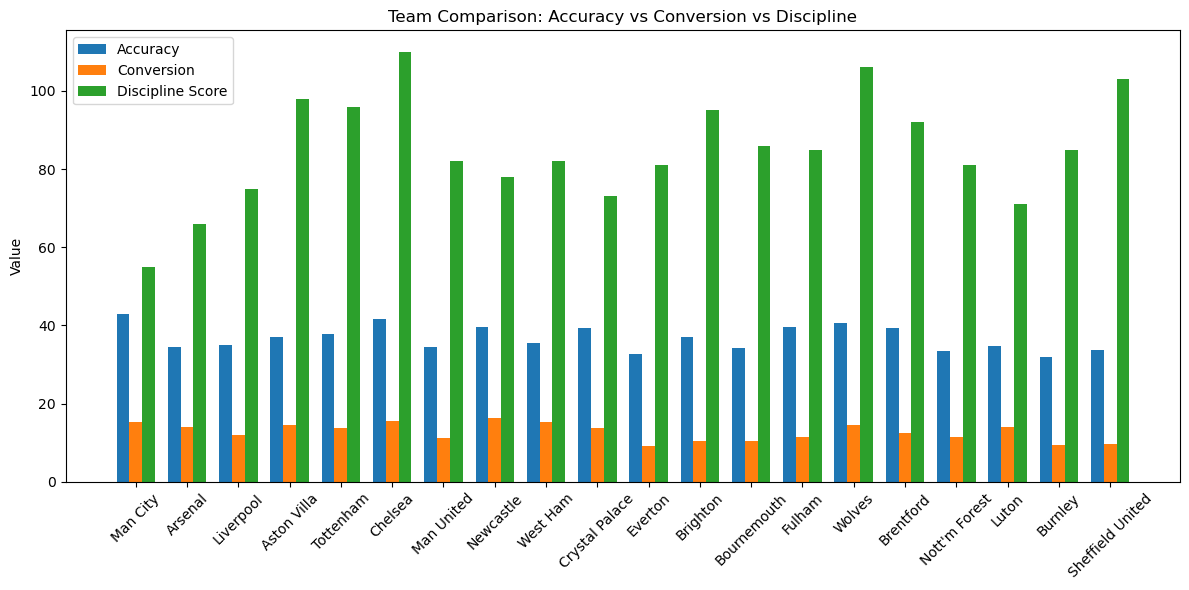

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Data
teams = team_summary["Team"]
accuracy = team_summary["Accuracy"]
conversion = team_summary["Conversion"]
discipline = team_summary["Discipline_Score"]

# X locations
x = np.arange(len(teams))
width = 0.25   # width of each bar

plt.figure(figsize=(12,6))

# Three grouped bars
plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, conversion, width, label="Conversion")
plt.bar(x + width, discipline, width, label="Discipline Score")

# X-axis labels
plt.xticks(x, teams, rotation=45)

plt.ylabel("Value")
plt.title("Team Comparison: Accuracy vs Conversion vs Discipline")
plt.legend()

plt.tight_layout()
plt.show()

In [78]:
team_summary.head(19)

,Team,Goals,Shots,Accuracy,Conversion,Yellow,Red,Points,Position,Discipline_Score
0,Man City,96,690,43.014918,15.270857,51,2,91,1,55
1,Arsenal,91,657,34.426856,13.873220,62,2,89,2,66
2,Liverpool,86,790,35.036890,11.953148,65,5,82,3,75
3,Aston Villa,76,514,37.031140,14.460051,94,2,68,4,98
4,Tottenham,74,582,37.793983,13.772467,88,4,66,5,96
5,Chelsea,77,548,41.616482,15.547042,104,3,63,6,110
6,Man United,57,550,34.514543,11.277680,80,1,60,7,82
7,Newcastle,85,551,39.463162,16.308912,76,1,60,8,78
8,West Ham,60,450,35.514916,15.198753,76,3,52,9,82
9,Crystal Palace,57,456,39.225285,13.760859,69,2,49,10,73
